In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

df = pd.read_csv("../data/credit_risk_clean.csv")
macro = pd.read_csv("../data/argentina_macro.csv")

print("Datos cargados OK")
print(f"Shape: {df.shape}")

Datos cargados OK
Shape: (32581, 12)


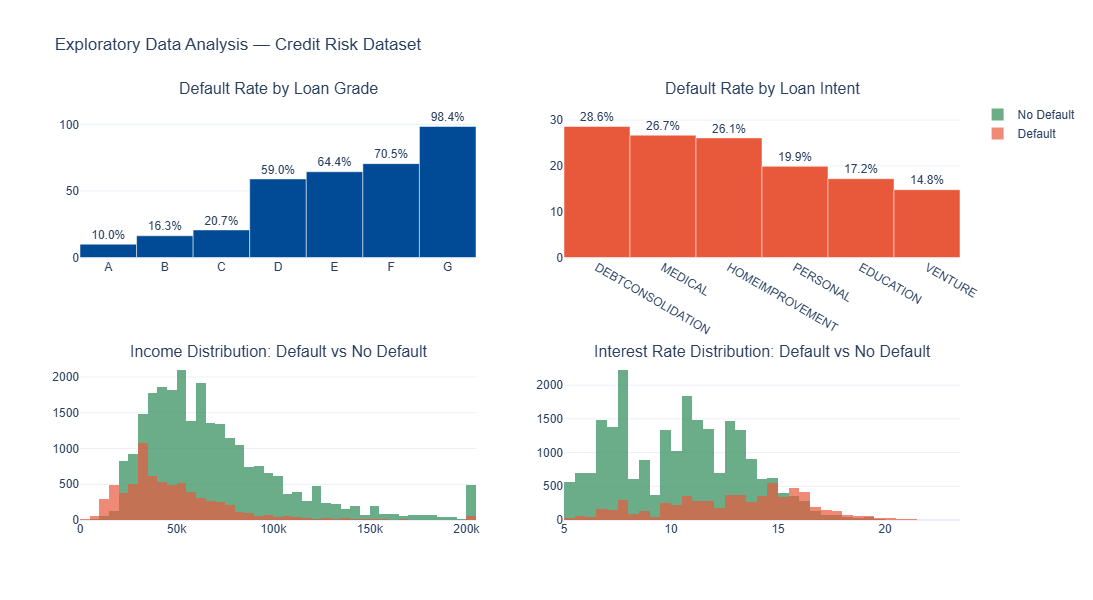

In [2]:
fig = make_subplots(rows=2, cols=2,
    subplot_titles=(
        "Default Rate by Loan Grade",
        "Default Rate by Loan Intent",
        "Income Distribution: Default vs No Default",
        "Interest Rate Distribution: Default vs No Default"
    ))

# 1. Default rate por loan grade
grade_default = df.groupby("loan_grade")["loan_status"].mean().reset_index()
grade_default["loan_status"] = (grade_default["loan_status"] * 100).round(1)

fig.add_trace(go.Bar(
    x=grade_default["loan_grade"],
    y=grade_default["loan_status"],
    marker_color="#004A96",
    showlegend=False,
    text=grade_default["loan_status"].astype(str) + "%",
    textposition="outside"
), row=1, col=1)

# 2. Default rate por loan intent
intent_default = df.groupby("loan_intent")["loan_status"].mean().reset_index()
intent_default["loan_status"] = (intent_default["loan_status"] * 100).round(1)
intent_default = intent_default.sort_values("loan_status", ascending=False)

fig.add_trace(go.Bar(
    x=intent_default["loan_intent"],
    y=intent_default["loan_status"],
    marker_color="#E8593C",
    showlegend=False,
    text=intent_default["loan_status"].astype(str) + "%",
    textposition="outside"
), row=1, col=2)

# 3. Income distribution
default_income = df[df["loan_status"] == 1]["person_income"].clip(upper=200000)
no_default_income = df[df["loan_status"] == 0]["person_income"].clip(upper=200000)

fig.add_trace(go.Histogram(
    x=no_default_income, name="No Default",
    marker_color="#2E8B57", opacity=0.7,
    showlegend=True, nbinsx=40
), row=2, col=1)

fig.add_trace(go.Histogram(
    x=default_income, name="Default",
    marker_color="#E8593C", opacity=0.7,
    showlegend=True, nbinsx=40
), row=2, col=1)

# 4. Interest rate distribution
fig.add_trace(go.Histogram(
    x=df[df["loan_status"] == 0]["loan_int_rate"],
    name="No Default", marker_color="#2E8B57",
    opacity=0.7, showlegend=False, nbinsx=40
), row=2, col=2)

fig.add_trace(go.Histogram(
    x=df[df["loan_status"] == 1]["loan_int_rate"],
    name="Default", marker_color="#E8593C",
    opacity=0.7, showlegend=False, nbinsx=40
), row=2, col=2)

fig.update_layout(
    title="Exploratory Data Analysis — Credit Risk Dataset",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=600,
    barmode="overlay"
)

fig.show()

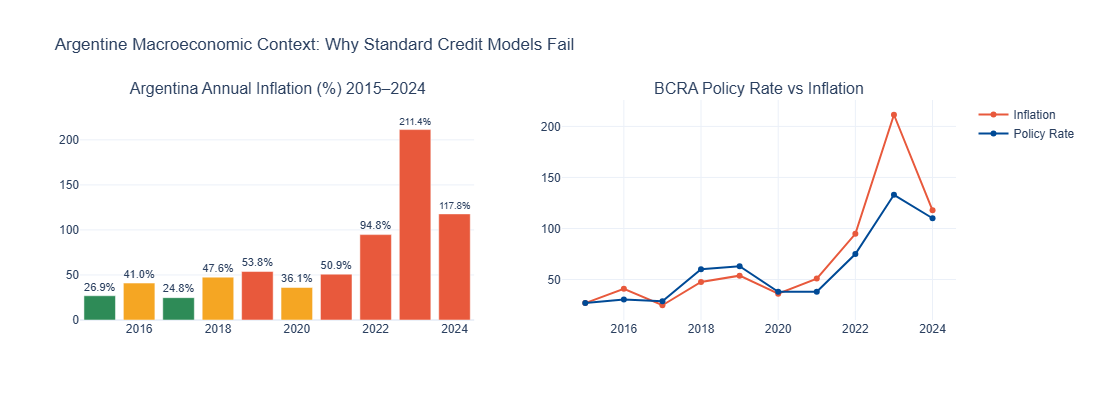

In [3]:
fig2 = make_subplots(rows=1, cols=2,
    subplot_titles=(
        "Argentina Annual Inflation (%) 2015–2024",
        "BCRA Policy Rate vs Inflation"
    ))

colors = ["#E8593C" if v > 50 else "#F5A623" if v > 30 else "#2E8B57"
          for v in macro["inflation_annual"]]

fig2.add_trace(go.Bar(
    x=macro["year"],
    y=macro["inflation_annual"],
    marker_color=colors,
    showlegend=False,
    text=macro["inflation_annual"].astype(str) + "%",
    textposition="outside"
), row=1, col=1)

fig2.add_trace(go.Scatter(
    x=macro["year"],
    y=macro["inflation_annual"],
    name="Inflation",
    line=dict(color="#E8593C", width=2),
    mode="lines+markers"
), row=1, col=2)

fig2.add_trace(go.Scatter(
    x=macro["year"],
    y=macro["lending_rate"],
    name="Policy Rate",
    line=dict(color="#004A96", width=2),
    mode="lines+markers"
), row=1, col=2)

fig2.update_layout(
    title="Argentine Macroeconomic Context: Why Standard Credit Models Fail",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=400
)

fig2.show()

In [4]:
print("=" * 55)
print("KEY FINDINGS — EDA")
print("=" * 55)

print(f"\nDataset: {len(df):,} loans | Default rate: {df['loan_status'].mean()*100:.1f}%")

print("\nDefault rate by loan grade:")
for _, row in grade_default.iterrows():
    bar = "█" * int(row["loan_status"] / 3)
    print(f"  Grade {row['loan_grade']}: {row['loan_status']:5.1f}%  {bar}")

print("\nTop 3 highest default intents:")
for _, row in intent_default.head(3).iterrows():
    print(f"  {row['loan_intent']:12}: {row['loan_status']}%")

print(f"\nInterest rate — defaulted loans:     {df[df['loan_status']==1]['loan_int_rate'].mean():.2f}%")
print(f"Interest rate — non-defaulted loans: {df[df['loan_status']==0]['loan_int_rate'].mean():.2f}%")

print(f"\nArgentina context:")
print(f"  Peak inflation (2023):  {macro['inflation_annual'].max():.1f}%")
print(f"  Peak policy rate:       {macro['lending_rate'].max():.1f}%")
print(f"  Avg inflation 2018–23:  {macro[macro['year']>=2018]['inflation_annual'].mean():.1f}%")
print("=" * 55)

KEY FINDINGS — EDA

Dataset: 32,581 loans | Default rate: 21.8%

Default rate by loan grade:
  Grade A:  10.0%  ███
  Grade B:  16.3%  █████
  Grade C:  20.7%  ██████
  Grade D:  59.0%  ███████████████████
  Grade E:  64.4%  █████████████████████
  Grade F:  70.5%  ███████████████████████
  Grade G:  98.4%  ████████████████████████████████

Top 3 highest default intents:
  DEBTCONSOLIDATION: 28.6%
  MEDICAL     : 26.7%
  HOMEIMPROVEMENT: 26.1%

Interest rate — defaulted loans:     13.06%
Interest rate — non-defaulted loans: 10.44%

Argentina context:
  Peak inflation (2023):  211.4%
  Peak policy rate:       133.0%
  Avg inflation 2018–23:  87.5%
